In [2]:
# =========================
# IMPORTS
# =========================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# =========================
# REPRODUCIBILITY
# =========================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# =========================
# DEVICE
# =========================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [3]:
CSV_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv"

df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)

df.head()

Shape: (112120, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [4]:
print(df.columns.tolist())

['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']


In [5]:
# Create binary classification dataset

pneumonia_df = df[
    df["Finding Labels"].str.contains("Pneumonia", na=False)
].copy()

normal_df = df[
    df["Finding Labels"] == "No Finding"
].copy()

pneumonia_df["label"] = 1
normal_df["label"] = 0

print("Pneumonia Images:", len(pneumonia_df))
print("Normal Images:", len(normal_df))

Pneumonia Images: 1431
Normal Images: 60361


In [6]:
normal_sampled = normal_df.sample(
    n=len(pneumonia_df),
    random_state=42
)

binary_df = pd.concat(
    [pneumonia_df, normal_sampled],
    ignore_index=True
)

binary_df = binary_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(binary_df["label"].value_counts())

label
0    1431
1    1431
Name: count, dtype: int64


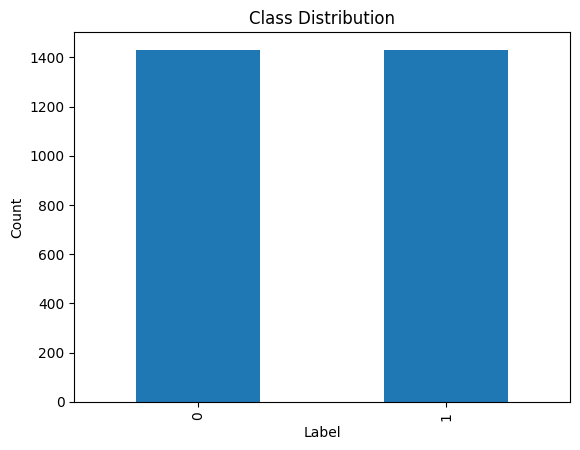

In [7]:
import matplotlib.pyplot as plt

binary_df["label"].value_counts().plot(
    kind="bar"
)

plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

In [8]:
import os

BASE_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"

image_paths = {}

for i in range(1, 13):
    
    folder = f"images_{i:03d}/images"
    
    full_path = os.path.join(BASE_PATH, folder)

    if not os.path.exists(full_path):
        continue

    for img in os.listdir(full_path):
        image_paths[img] = os.path.join(
            full_path,
            img
        )

print("Total Images Found:", len(image_paths))

Total Images Found: 112120


In [17]:
# Recreate balanced dataset

pneumonia_df = df[
    df["Finding Labels"].str.contains("Pneumonia", na=False)
].copy()

normal_df = df[
    df["Finding Labels"] == "No Finding"
].copy()

pneumonia_df["label"] = 1
normal_df["label"] = 0

normal_sampled = normal_df.sample(
    n=len(pneumonia_df),
    random_state=42
)

binary_df = pd.concat(
    [pneumonia_df, normal_sampled],
    ignore_index=True
)

binary_df = binary_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(binary_df.shape)

(2862, 13)


In [18]:
print("CSV filename:")
print(binary_df["Image Index"].iloc[0])

print("\nDictionary filename:")
print(list(image_paths.keys())[0])

CSV filename:
00014355_003.png

Dictionary filename:
00000502_003.png


In [19]:
target_file = binary_df["Image Index"].iloc[0]

print("Target File:", target_file)

print("\nExists in dictionary?")
print(target_file in image_paths)

if target_file in image_paths:
    print("\nPath:")
    print(image_paths[target_file])

Target File: 00014355_003.png

Exists in dictionary?
True

Path:
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_007/images/00014355_003.png


In [20]:
print("Total keys in image_paths:", len(image_paths))

sample_keys = list(image_paths.keys())[:10]

for key in sample_keys:
    print(key)

Total keys in image_paths: 112120
00000502_003.png
00001255_008.png
00001304_001.png
00000003_003.png
00000926_002.png
00000618_000.png
00000370_010.png
00000315_004.png
00001043_004.png
00001248_017.png


In [21]:
binary_df["image_path"] = binary_df["Image Index"].map(image_paths)

print("Total rows:", len(binary_df))
print("Missing paths:", binary_df["image_path"].isna().sum())

binary_df[["Image Index", "image_path"]].head()

Total rows: 2862
Missing paths: 0


,Image Index,image_path
0,00014355_003.png,/kaggle/input/datasets/organizations/nih-chest...
1,00008139_000.png,/kaggle/input/datasets/organizations/nih-chest...
2,00015376_026.png,/kaggle/input/datasets/organizations/nih-chest...
3,00015003_001.png,/kaggle/input/datasets/organizations/nih-chest...
4,00009302_008.png,/kaggle/input/datasets/organizations/nih-chest...


In [22]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    binary_df,
    test_size=0.20,
    stratify=binary_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain Distribution")
print(train_df["label"].value_counts())

print("\nValidation Distribution")
print(val_df["label"].value_counts())

print("\nTest Distribution")
print(test_df["label"].value_counts())

Train: 2289
Validation: 286
Test: 287

Train Distribution
label
1    1145
0    1144
Name: count, dtype: int64

Validation Distribution
label
1    143
0    143
Name: count, dtype: int64

Test Distribution
label
0    144
1    143
Name: count, dtype: int64


In [23]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [24]:
from torch.utils.data import Dataset
from PIL import Image

class ChestXrayDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        image_path = self.df.iloc[idx]["image_path"]

        label = int(
            self.df.iloc[idx]["label"]
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [25]:
train_dataset = ChestXrayDataset(
    train_df,
    transform=train_transform
)

val_dataset = ChestXrayDataset(
    val_df,
    transform=val_transform
)

test_dataset = ChestXrayDataset(
    test_df,
    transform=val_transform
)

print("Train Dataset:", len(train_dataset))
print("Validation Dataset:", len(val_dataset))
print("Test Dataset:", len(test_dataset))

Train Dataset: 2289
Validation Dataset: 286
Test Dataset: 287


In [26]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("DataLoaders Ready")

DataLoaders Ready


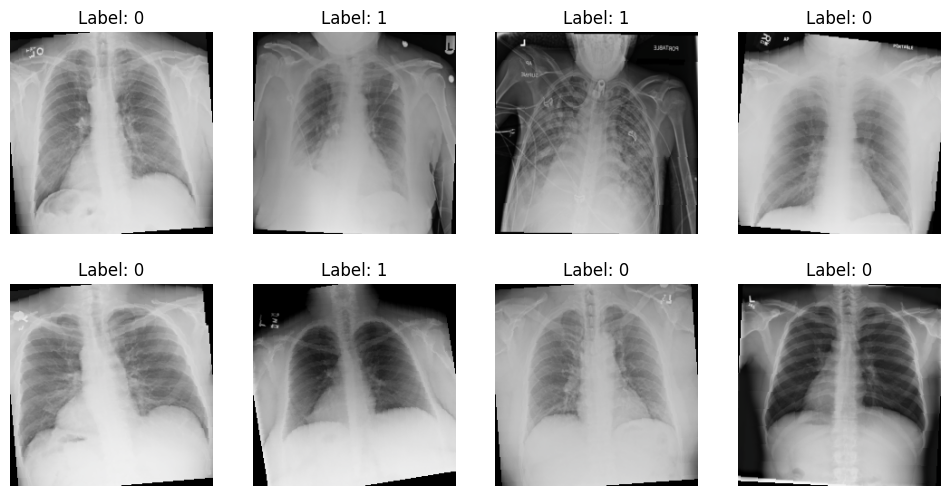

In [27]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2,4, figsize=(12,6))

for i, ax in enumerate(axes.flat):

    img = images[i].permute(1,2,0).numpy()

    img = img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])

    img = np.clip(img,0,1)

    ax.imshow(img)

    ax.set_title(
        f"Label: {labels[i].item()}"
    )

    ax.axis("off")

plt.show()

In [31]:
import torchvision.models as models
import torch.nn as nn

model = models.densenet121(weights="IMAGENET1K_V1")

num_features = model.classifier.in_features

model.classifier = nn.Linear(
    num_features,
    2
)

model = model.to(device)

print("Model Loaded Successfully")
print("Output Features:", num_features)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 202MB/s]


Model Loaded Successfully
Output Features: 1024


In [32]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

print("Loss and Optimizer Ready")

Loss and Optimizer Ready


In [33]:
from tqdm import tqdm

def train_one_epoch(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [34]:
def validate(model, loader):

    model.eval()

    running_loss = 0

    preds_all = []
    labels_all = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            preds_all.extend(
                preds.cpu().numpy()
            )

            labels_all.extend(
                labels.cpu().numpy()
            )

    val_loss = running_loss / len(loader)

    acc = accuracy_score(
        labels_all,
        preds_all
    )

    precision = precision_score(
        labels_all,
        preds_all
    )

    recall = recall_score(
        labels_all,
        preds_all
    )

    f1 = f1_score(
        labels_all,
        preds_all
    )

    return (
        val_loss,
        acc,
        precision,
        recall,
        f1
    )

In [35]:
EPOCHS = 5

best_f1 = 0

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc, precision, recall, f1 = validate(
        model,
        val_loader
    )

    scheduler.step(f1)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")

    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"F1 Score   : {f1:.4f}")

    if f1 > best_f1:

        best_f1 = f1

        torch.save(
            model.state_dict(),
            "best_densenet.pth"
        )

        print("Best Model Saved")

100%|██████████| 72/72 [00:35<00:00,  2.01it/s]



Epoch 1/5
Train Loss : 0.5948
Train Acc  : 0.6872
Val Loss   : 0.5484
Val Acc    : 0.7517
Precision  : 0.7903
Recall     : 0.6853
F1 Score   : 0.7341
Best Model Saved


100%|██████████| 72/72 [00:29<00:00,  2.44it/s]



Epoch 2/5
Train Loss : 0.5394
Train Acc  : 0.7291
Val Loss   : 0.5193
Val Acc    : 0.7657
Precision  : 0.7235
Recall     : 0.8601
F1 Score   : 0.7859
Best Model Saved


100%|██████████| 72/72 [00:30<00:00,  2.36it/s]



Epoch 3/5
Train Loss : 0.5028
Train Acc  : 0.7584
Val Loss   : 0.4993
Val Acc    : 0.7762
Precision  : 0.8211
Recall     : 0.7063
F1 Score   : 0.7594


100%|██████████| 72/72 [00:29<00:00,  2.43it/s]



Epoch 4/5
Train Loss : 0.4403
Train Acc  : 0.7995
Val Loss   : 0.5167
Val Acc    : 0.7657
Precision  : 0.7714
Recall     : 0.7552
F1 Score   : 0.7633


100%|██████████| 72/72 [00:29<00:00,  2.40it/s]



Epoch 5/5
Train Loss : 0.4136
Train Acc  : 0.8148
Val Loss   : 0.5523
Val Acc    : 0.7308
Precision  : 0.6988
Recall     : 0.8112
F1 Score   : 0.7508


In [36]:
model.load_state_dict(
    torch.load(
        "best_densenet.pth",
        map_location=device
    )
)

print("Best model loaded")

Best model loaded


In [37]:
test_loss, test_acc, precision, recall, f1 = validate(
    model,
    test_loader
)

print("\nFINAL TEST RESULTS")

print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


FINAL TEST RESULTS
Accuracy  : 0.7213
Precision : 0.6703
Recall    : 0.8671
F1 Score  : 0.7561


In [38]:
from sklearn.metrics import confusion_matrix

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

cm = confusion_matrix(
    all_labels,
    all_preds
)

print(cm)

[[ 83  61]
 [ 19 124]]


In [40]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class ArcMarginProduct(nn.Module):
    
    def __init__(
        self,
        in_features,
        out_features,
        s=30.0,
        m=0.50
    ):
        super().__init__()

        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m

        self.weight = nn.Parameter(
            torch.FloatTensor(
                out_features,
                in_features
            )
        )

        nn.init.xavier_uniform_(
            self.weight
        )

    def forward(self, input, label):

        cosine = F.linear(
            F.normalize(input),
            F.normalize(self.weight)
        )

        sine = torch.sqrt(
            1.0 - torch.pow(cosine, 2)
        )

        phi = (
            cosine * math.cos(self.m)
            - sine * math.sin(self.m)
        )

        one_hot = torch.zeros_like(cosine)

        one_hot.scatter_(
            1,
            label.view(-1,1),
            1
        )

        output = (
            one_hot * phi
            + (1.0 - one_hot) * cosine
        )

        output *= self.s

        return output

In [41]:
import torchvision.models as models

class DenseNetArcFace(nn.Module):

    def __init__(self):

        super().__init__()

        backbone = models.densenet121(
            weights="IMAGENET1K_V1"
        )

        num_features = (
            backbone.classifier.in_features
        )

        backbone.classifier = nn.Identity()

        self.backbone = backbone

        self.embedding = nn.Linear(
            num_features,
            512
        )

        self.bn = nn.BatchNorm1d(
            512
        )

        self.arcface = ArcMarginProduct(
            512,
            2
        )

    def forward(
        self,
        images,
        labels=None
    ):

        features = self.backbone(images)

        embeddings = self.embedding(
            features
        )

        embeddings = self.bn(
            embeddings
        )

        if labels is not None:

            logits = self.arcface(
                embeddings,
                labels
            )

            return logits

        return embeddings

In [42]:
arc_model = DenseNetArcFace().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    arc_model.parameters(),
    lr=1e-4
)

print("ArcFace Model Ready")

ArcFace Model Ready


In [43]:
from tqdm import tqdm

def train_arcface_epoch():

    arc_model.train()

    running_loss = 0

    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = arc_model(
            images,
            labels
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    return (
        running_loss / len(train_loader),
        correct / total
    )

In [44]:
def validate_arcface():

    arc_model.eval()

    preds_all = []
    labels_all = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = arc_model(
                images,
                labels
            )

            preds = outputs.argmax(1)

            preds_all.extend(
                preds.cpu().numpy()
            )

            labels_all.extend(
                labels.cpu().numpy()
            )

    acc = accuracy_score(
        labels_all,
        preds_all
    )

    precision = precision_score(
        labels_all,
        preds_all
    )

    recall = recall_score(
        labels_all,
        preds_all
    )

    f1 = f1_score(
        labels_all,
        preds_all
    )

    return (
        acc,
        precision,
        recall,
        f1
    )

In [47]:
EPOCHS = 30

best_f1 = 0

for epoch in range(EPOCHS):

    train_loss, train_acc = (
        train_arcface_epoch()
    )

    acc, precision, recall, f1 = (
        validate_arcface()
    )

    print(
        f"\nEpoch {epoch+1}"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Train Acc : {train_acc:.4f}"
    )

    print(
        f"Val Acc   : {acc:.4f}"
    )

    print(
        f"Precision : {precision:.4f}"
    )

    print(
        f"Recall    : {recall:.4f}"
    )

    print(
        f"F1 Score  : {f1:.4f}"
    )

    if f1 > best_f1:

        best_f1 = f1

        torch.save(
            arc_model.state_dict(),
            "best_arcface.pth"
        )

100%|██████████| 72/72 [00:31<00:00,  2.26it/s]



Epoch 1
Train Loss: 4.0912
Train Acc : 0.5850
Val Acc   : 0.4895
Precision : 0.4889
Recall    : 0.4615
F1 Score  : 0.4748


100%|██████████| 72/72 [00:30<00:00,  2.38it/s]



Epoch 2
Train Loss: 3.1381
Train Acc : 0.6540
Val Acc   : 0.5210
Precision : 0.5278
Recall    : 0.3986
F1 Score  : 0.4542


100%|██████████| 72/72 [00:30<00:00,  2.36it/s]


...


Epoch 28
Train Loss: 0.2940
Train Acc : 0.9655
Val Acc   : 0.9965
Precision : 0.9931
Recall    : 1.0000
F1 Score  : 0.9965


100%|██████████| 72/72 [00:30<00:00,  2.33it/s]



Epoch 29
Train Loss: 0.3804
Train Acc : 0.9493
Val Acc   : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000


100%|██████████| 72/72 [00:34<00:00,  2.11it/s]



Epoch 30
Train Loss: 0.4055
Train Acc : 0.9493
Val Acc   : 0.9965
Precision : 0.9931
Recall    : 1.0000
F1 Score  : 0.9965


In [4]:
arc_model = DenseNetArcFace().to(device)

arc_model.load_state_dict(
    torch.load(
        "best_arcface.pth",
        map_location=device
    )
)

arc_model.eval()

print("ArcFace model loaded successfully")

NameError: name 'DenseNetArcFace' is not defined